### Dependencies

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, Xception
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from pathlib import Path 
import pandas as pd        
import keras
import numpy as np
import os, json
from glob import glob
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

### Data Paths

In [2]:
DATA_PATH_ANN="../data/annotations"
DATA_PATH_IMG="../data/images"

Image


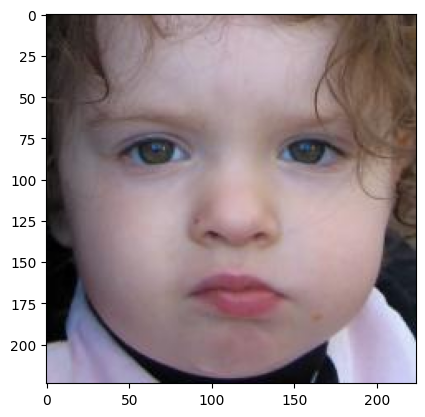

In [4]:
# Image
print("Image")
img=plt.imread(f"{DATA_PATH_IMG}/0.jpg")
plt.imshow(img)

#### 0: Neutral, 1: Happy, 2: Sad, 3: Surprise, 4: Fear, 5: Disgust, 6: Anger, 7: Contempt

In [5]:
# Expression
exp=np.load(f"{DATA_PATH_ANN}/0_exp.npy")
print("Expression: ", exp)
print("Shape:", exp.shape)
print("Data type:", exp.dtype) 

Expression:  0
Shape: ()
Data type: <U1


#### Range [-1,+1] (for Uncertain and Noface categories the value is -2) 
#### Continuous values from -1 (negative/unpleasant) to +1 (positive/pleasant)

In [6]:
# Valence
val=np.load(f"{DATA_PATH_ANN}/0_val.npy")
print("Valence: ", val)
print("Shape:", val.shape)
print("Data type:", val.dtype) 

Valence:  -0.176846
Shape: ()
Data type: <U9


#### Range [-1,+1] (for Uncertain and Noface categories the value is -2) 
#### Continuous values from -1 (Tires) to +1 (Active)

In [7]:
# Arousal
aro=np.load(f"{DATA_PATH_ANN}/0_aro.npy")
print("Arousal: ", aro)
print("Shape:", aro.shape)
print("Data type:", aro.dtype) 

Arousal:  -0.0776398
Shape: ()
Data type: <U10


#### Location of the 68 facial landmarks

In [8]:
# Landmark
lnd=np.load(f"{DATA_PATH_ANN}/0_lnd.npy")
print("Landmark: ", lnd)
print("Shape:", lnd.shape)
print("Data type:", lnd.dtype) 

Landmark:  [-6.66666667e-03  8.14980117e+01  2.81000000e+00  1.07939181e+02
  8.13666667e+00  1.34373801e+02  1.53233333e+01  1.58335906e+02
  2.76100000e+01  1.80454269e+02  4.71566667e+01  1.98033684e+02
  6.91700000e+01  2.11663626e+02  9.08000000e+01  2.21347368e+02
  1.11950000e+02  2.24602573e+02  1.32963333e+02  2.21380117e+02
  1.53270000e+02  2.10749942e+02  1.72553333e+02  1.97293567e+02
  1.91013333e+02  1.81544795e+02  2.02653333e+02  1.60559532e+02
  2.09523333e+02  1.36106199e+02  2.14586667e+02  1.08826667e+02
  2.16303333e+02  7.93169591e+01  1.65166667e+01  6.81300585e+01
  3.25433333e+01  5.78863158e+01  5.25433333e+01  5.68449123e+01
  7.39066667e+01  6.00149708e+01  9.42966667e+01  6.67316959e+01
  1.28733333e+02  6.53791813e+01  1.51076667e+02  5.92879532e+01
  1.71943333e+02  5.56921637e+01  1.91793333e+02  5.83513450e+01
  2.05030000e+02  7.07564912e+01  1.12133333e+02  8.55064327e+01
  1.12260000e+02  9.97880702e+01  1.12353333e+02  1.13666901e+02
  1.12570000e+

In [ ]:
resNet = ResNet50(weights="imagenet")

# Print the architecture
resNet.summary()

In [ ]:
xception = Xception(weights="imagenet")

xception.summary()

In [3]:
IMG_SIZE = (128,128)
BATCH_SIZE = 24
EPOCHS = 35
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Get all images
img_paths = sorted(glob(os.path.join(DATA_PATH_IMG, "*.jpg")))

records = []
landmarks_list = []

for img_path in img_paths:
    base = os.path.splitext(os.path.basename(img_path))[0]  # e.g. "0"
    exp_file = os.path.join(DATA_PATH_ANN, f"{base}_exp.npy")
    val_file = os.path.join(DATA_PATH_ANN, f"{base}_val.npy")
    aro_file = os.path.join(DATA_PATH_ANN, f"{base}_aro.npy")
    lnd_file = os.path.join(DATA_PATH_ANN, f"{base}_lnd.npy")

    # Load each annotation (each is a tiny .npy file)
    expression = int(np.load(exp_file))
    valence = float(np.load(val_file))
    arousal = float(np.load(aro_file))
    landmark = np.load(lnd_file)

    # Flatten landmarks if 68x2
    if landmark.ndim == 2 and landmark.shape[1] == 2:
        landmark = landmark.reshape(-1)

    records.append([img_path, expression, valence, arousal])
    landmarks_list.append(landmark)

# Make DataFrame and landmarks array
df = pd.DataFrame(records, columns=["image_path", "expression", "valence", "arousal"])
landmarks_array = np.array(landmarks_list, dtype="float32")

print("Dataset size:", len(df))
print("Expression classes:", np.unique(df["expression"]))
print("Landmarks shape:", landmarks_array.shape)

Dataset size: 3999
Expression classes: [0 1 2 3 4 5 6 7]
Landmarks shape: (3999, 136)


In [23]:
df.head()

,image_path,expression,valence,arousal
0,../data/images\0.jpg,0,-0.176846,-0.077640
1,../data/images\1.jpg,0,-0.367789,0.183895
2,../data/images\10.jpg,7,-0.648471,0.658149
3,../data/images\100.jpg,3,0.150794,0.666667
4,../data/images\1001.jpg,0,-0.135501,0.004839


In [5]:
# --- Split into train/val ---
train_df, val_df, train_landmarks, val_landmarks = train_test_split(
    df, landmarks_array, test_size=0.2, stratify=df["expression"], random_state=SEED
)

# --- Helper to load images ---
def _load_image(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)   # force RGB
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# --- Dataset builder ---
def make_multimodal_dataset(df_subset, lm_array, batch_size=BATCH_SIZE, shuffle=False):
    def gen():
        for p, exp, val, aro, lm in zip(
            df_subset["image_path"], df_subset["expression"],
            df_subset["valence"], df_subset["arousal"], lm_array
        ):
            yield p.encode("utf-8"), lm.astype("float32"), exp, np.array([val, aro], dtype="float32")
    
    output_types = (tf.string, tf.float32, tf.int64, tf.float32)
    output_shapes = ((), (lm_array.shape[1],), (), (2,))
    ds = tf.data.Dataset.from_generator(gen, output_types=output_types, output_shapes=output_shapes)
    
    def _map(path, lm, exp, va):
        img = _load_image(path)
        return {"image_input": img, "lm_input": lm}, {"expr_out": tf.one_hot(exp, df["expression"].nunique()), "va_out": va}
    
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --- Create train/val datasets ---
train_ds = make_multimodal_dataset(train_df, train_landmarks, shuffle=True)
val_ds   = make_multimodal_dataset(val_df, val_landmarks, shuffle=False)

print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), 'lm_input': TensorSpec(shape=(None, 136), dtype=tf.float32, name=None)}, {'expr_out': TensorSpec(shape=(None, 8), dtype=tf.float32, name=None), 'va_out': TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)})>
<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), 'lm_input': TensorSpec(shape=(None, 136), dtype=tf.float32, name=None)}, {'expr_out': TensorSpec(shape=(None, 8), dtype=tf.float32, name=None), 'va_out': TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)})>


In [6]:
IMG_SHAPE = (128, 128, 3)
LM_DIM = train_landmarks.shape[1]
NUM_CLASSES = df["expression"].nunique()

def build_resnet_with_landmarks(img_shape=IMG_SHAPE, lm_dim=LM_DIM, freeze_backbone=True):
    # --- Image branch (ResNet50) ---
    img_in = layers.Input(shape=img_shape, name="image_input")
    base = ResNet50(weights="imagenet", include_top=False, input_tensor=img_in)
    if freeze_backbone:
        base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    img_feat = layers.Dense(256, activation="relu")(x)

    # --- Landmark branch ---
    lm_in = layers.Input(shape=(lm_dim,), name="lm_input")
    y = layers.Dense(128, activation="relu")(lm_in)
    y = layers.Dropout(0.3)(y)
    lm_feat = layers.Dense(64, activation="relu")(y)

    # --- Fusion ---
    fused = layers.Concatenate()([img_feat, lm_feat])
    fused = layers.Dense(256, activation="relu")(fused)
    fused = layers.Dropout(0.4)(fused)

    # --- Heads ---
    expr_out = layers.Dense(NUM_CLASSES, activation="softmax", name="expr_out")(fused)
    va_out = layers.Dense(2, activation="tanh", name="va_out")(fused)

    model = models.Model(inputs=[img_in, lm_in], outputs=[expr_out, va_out])
    return model

# Build model with frozen backbone first
model = build_resnet_with_landmarks(freeze_backbone=True)

# Unfreeze last ~30 layers (fine-tuning)
for layer in model.layers[-100:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

# Re-compile with smaller learning rate for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # <-- smaller LR
    loss={"expr_out": "categorical_crossentropy", "va_out": "mse"},
    loss_weights={"expr_out": 1.0, "va_out": 1.0},
    metrics={"expr_out": "accuracy"}
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,878,666 (94.90 MB)

 Trainable params: 22,085,834 (84.25 MB)

 Non-trainable params: 2,792,832 (10.65 MB)

In [7]:
# --- Callbacks ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet_landmarks.h5", monitor="val_expr_out_accuracy",
        save_best_only=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_expr_out_accuracy", factor=0.5, patience=3,
        mode="max", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_expr_out_accuracy", patience=7,
        mode="max", restore_best_weights=True, verbose=1
    )
]

# --- Train ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/35
    134/Unknown 122s 785ms/step - expr_out_accuracy: 0.1415 - expr_out_loss: 67.8921 - loss: 68.9175 - va_out_loss: 1.0252

c:\Users\ismai\OneDrive\Desktop\CNN_FacialExpression_DeepLearning\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_expr_out_accuracy improved from None to 0.13375, saving model to best_resnet_landmarks.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 139s 908ms/step - expr_out_accuracy: 0.1313 - expr_out_loss: 59.0988 - loss: 60.5478 - va_out_loss: 0.9712 - val_expr_out_accuracy: 0.1338 - val_expr_out_loss: 8.5701 - val_loss: 9.6220 - val_va_out_loss: 0.7108 - learning_rate: 1.0000e-05
Epoch 2/35


AlreadyExistsError: Graph execution error:

Detected at node StatefulPartitionedCall/compile_loss/ArithmeticOptimizer/AddOpsRewrite_add_5/tmp_var defined at (most recent call last):
<stack traces unavailable>
Resource __per_step_0/StatefulPartitionedCall/compile_loss/ArithmeticOptimizer/AddOpsRewrite_add_5/tmp_var/frame:0/iter:0/struct tensorflow::TemporaryVariableOp::TmpVar
	 [[{{node StatefulPartitionedCall/compile_loss/ArithmeticOptimizer/AddOpsRewrite_add_5/tmp_var}}]] [Op:__inference_multi_step_on_iterator_20690]

In [8]:
# Phase 1: Build frozen model
model = build_resnet_with_landmarks(freeze_backbone=True)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss={"expr_out": "categorical_crossentropy", "va_out": "mse"},
    loss_weights={"expr_out": 1.0, "va_out": 1.0},
    metrics={"expr_out": "accuracy"}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("warmup_resnet.h5", monitor="val_expr_out_accuracy",
                                       save_best_only=True, mode="max", verbose=1)
]

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
    134/Unknown 62s 383ms/step - expr_out_accuracy: 0.1145 - expr_out_loss: 46.9639 - loss: 48.4250 - va_out_loss: 1.4606
Epoch 1: val_expr_out_accuracy improved from None to 0.12500, saving model to warmup_resnet.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 503ms/step - expr_out_accuracy: 0.1229 - expr_out_loss: 32.2096 - loss: 33.8430 - va_out_loss: 1.3131 - val_expr_out_accuracy: 0.1250 - val_expr_out_loss: 5.0151 - val_loss: 5.8472 - val_va_out_loss: 0.7067
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - expr_out_accuracy: 0.1195 - expr_out_loss: 10.9925 - loss: 11.9329 - va_out_loss: 0.9402
Epoch 2: val_expr_out_accuracy improved from 0.12500 to 0.13625, saving model to warmup_resnet.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 473ms/step - expr_out_accuracy: 0.1194 - expr_out_loss: 8.0770 - loss: 9.0213 - va_out_loss: 0.8489 - val_expr_out_accuracy: 0.1363 - val_expr_out_loss: 2.1479 - val_loss: 2.7533 - val_va_out_loss: 0.5395
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - expr_out_accuracy: 0.1269 - expr_out_loss: 3.2294 - loss: 3.8735 - va_out_loss: 0.6441
Epoch 3: val_expr_out_accuracy improved from 0.13625 to 0.14125, saving model to warmup_resnet.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 473ms/step - expr_out_accuracy: 0.1216 - expr_out_loss: 2.7518 - loss: 3.3233 - va_out_loss: 0.5439 - val_expr_out_accuracy: 0.1412 - val_expr_out_loss: 2.0170 - val_loss: 2.2947 - val_va_out_loss: 0.2145
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - expr_out_accuracy: 0.1164 - expr_out_loss: 2.1665 - loss: 2.4789 - va_out_loss: 0.3124
Epoch 4: val_expr_out_accuracy did not improve from 0.14125
134/134 ━━━━━━━━━━━━━━━━━━━━ 64s 471ms/step - expr_out_accuracy: 0.1191 - expr_out_loss: 2.1270 - loss: 2.4163 - va_out_loss: 0.2722 - val_expr_out_accuracy: 0.1312 - val_expr_out_loss: 2.0187 - val_loss: 2.3138 - val_va_out_loss: 0.2306
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - expr_out_accuracy: 0.1277 - expr_out_loss: 2.1016 - loss: 2.3378 - va_out_loss: 0.2362
Epoch 5: val_expr_out_accuracy did not improve from 0.14125
134/134 ━━━━━━━━━━━━━━━━━━━━ 65s 484ms/step - expr_out_accuracy: 0.1300 - expr_out_loss: 2.0825 - loss: 2.3275 - va_ou

In [10]:
# Clear old graph
tf.keras.backend.clear_session()

# Reload best warmup weights into a fresh model
model = build_resnet_with_landmarks(freeze_backbone=True)
model.load_weights("warmup_resnet.h5")

# Re-compile with smaller LR
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss={"expr_out": "categorical_crossentropy", "va_out": "mse"},
    loss_weights={"expr_out": 1.0, "va_out": 1.0},
    metrics={"expr_out": "accuracy"}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("finetuned_resnet.h5", monitor="val_expr_out_accuracy",
                                       save_best_only=True, mode="max", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_expr_out_accuracy", factor=0.5, patience=3, mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_expr_out_accuracy", patience=7, mode="max", restore_best_weights=True)
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
    134/Unknown 71s 461ms/step - expr_out_accuracy: 0.1377 - expr_out_loss: 2.2011 - loss: 2.5288 - va_out_loss: 0.3277
Epoch 1: val_expr_out_accuracy improved from None to 0.14750, saving model to finetuned_resnet.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 88s 589ms/step - expr_out_accuracy: 0.1272 - expr_out_loss: 2.1668 - loss: 2.4974 - va_out_loss: 0.3115 - val_expr_out_accuracy: 0.1475 - val_expr_out_loss: 2.0157 - val_loss: 2.3018 - val_va_out_loss: 0.2219 - learning_rate: 1.0000e-05
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - expr_out_accuracy: 0.1283 - expr_out_loss: 2.1358 - loss: 2.4208 - va_out_loss: 0.2850
Epoch 2: val_expr_out_accuracy improved from 0.14750 to 0.15125, saving model to finetuned_resnet.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 76s 564ms/step - expr_out_accuracy: 0.1319 - expr_out_loss: 2.1148 - loss: 2.4117 - va_out_loss: 0.2785 - val_expr_out_accuracy: 0.1513 - val_expr_out_loss: 2.0147 - val_loss: 2.3018 - val_va_out_loss: 0.2225 - learning_rate: 1.0000e-05
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - expr_out_accuracy: 0.1323 - expr_out_loss: 2.1133 - loss: 2.3718 - va_out_loss: 0.2585
Epoch 3: val_expr_out_accuracy did not improve from 0.15125
134/134 ━━━━━━━━━━━━━━━━━━━━ 76s 558ms/step - expr_out_accuracy: 0.1304 - expr_out_loss: 2.0960 - loss: 2.3694 - va_out_loss: 0.2553 - val_expr_out_accuracy: 0.1400 - val_expr_out_loss: 2.0161 - val_loss: 2.2972 - val_va_out_loss: 0.2169 - learning_rate: 1.0000e-05
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - expr_out_accuracy: 0.1276 - expr_out_loss: 2.1158 - loss: 2.3611 - va_out_loss: 0.2452
Epoch 4: val_expr_out_accuracy did not improve from 0.15125
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 611ms/step - expr_out_accurac

In [16]:
# ==========================
# 1. Imports
# ==========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np
from pathlib import Path
import json

# metrics
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from scipy.stats import pearsonr

# plotting (optional for confusion matrix / report)
import matplotlib.pyplot as plt

# if needed
from PIL import Image

from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms

# optional timm
try:
    import timm

    TIMM_AVAILABLE = True
except Exception:
    TIMM_AVAILABLE = False

In [13]:
# ==========================
# 2. Config
# ==========================
DATA_PATH_IMG = "../data/images"        # <-- change if needed
DATA_PATH_ANN = "../data/annotations"   # <-- change if needed
IMG_SIZE = 128
BATCH_SIZE = 24
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class CFG:
    IMG_SIZE = 128
    BATCH_SIZE = 24
    NUM_WORKERS = 4
    LR = 1e-4
    EPOCHS = 25
    SEED = 42
    SAVE_DIR = Path("outputs")
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    PRINT_FREQ = 50

In [17]:
# ==========================
# 3. Dataset
# ==========================
class AffectDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform

        self.img_paths = sorted(glob(os.path.join(img_dir, "*.jpg")))

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        base = os.path.splitext(os.path.basename(img_path))[0]

        exp_file = os.path.join(self.ann_dir, f"{base}_exp.npy")
        val_file = os.path.join(self.ann_dir, f"{base}_val.npy")
        aro_file = os.path.join(self.ann_dir, f"{base}_aro.npy")
        lnd_file = os.path.join(self.ann_dir, f"{base}_lnd.npy")

        # Load
        image = Image.open(img_path).convert("RGB")
        expression = int(np.load(exp_file))
        valence = float(np.load(val_file))
        arousal = float(np.load(aro_file))
        landmark = np.load(lnd_file)

        if landmark.ndim == 2:  # flatten 68x2 -> 136
            landmark = landmark.reshape(-1)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "landmarks": torch.tensor(landmark, dtype=torch.float32),
            "expression": torch.tensor(expression, dtype=torch.long),
            "valence": torch.tensor(valence, dtype=torch.float32),
            "arousal": torch.tensor(arousal, dtype=torch.float32),
        }

def collate_fn(batch):
    return {
        "image": torch.stack([b["image"] for b in batch]),
        "landmarks": torch.stack([b["landmarks"] for b in batch]),
        "expression": torch.stack([b["expression"] for b in batch]),
        "valence": torch.stack([b["valence"] for b in batch]),
        "arousal": torch.stack([b["arousal"] for b in batch]),
    }

In [18]:
# ==========================
# 4. Model
# ==========================
class MultiTaskModel(nn.Module):
    def __init__(self, num_classes=8, lm_dim=136, backbone_name="resnet50", pretrained=False):
        super().__init__()
        if backbone_name == "resnet50":
            base = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
        else:
            raise ValueError("Only resnet50 implemented here")

        # remove FC
        modules = list(base.children())[:-1]
        self.cnn = nn.Sequential(*modules)
        feat_dim = base.fc.in_features

        # CNN branch
        self.cnn_fc = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Landmarks branch
        self.lm_fc = nn.Sequential(
            nn.Linear(lm_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(256 + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Heads
        self.expr_head = nn.Linear(256, num_classes)
        self.va_head = nn.Linear(256, 2)

    def forward(self, x_img, x_lm):
        feat_img = self.cnn(x_img).view(x_img.size(0), -1)
        feat_img = self.cnn_fc(feat_img)

        feat_lm = self.lm_fc(x_lm)

        fused = self.fusion(torch.cat([feat_img, feat_lm], dim=1))

        expr_logits = self.expr_head(fused)
        va_out = self.va_head(fused)

        return expr_logits, va_out

In [19]:
# ==========================
# 5. Metrics (classification + regression)
# ==========================
def ccc(a, b):
    a_mean, b_mean = a.mean(), b.mean()
    cov = ((a - a_mean) * (b - b_mean)).mean()
    var_a, var_b = a.var(), b.var()
    return (2 * cov) / (var_a + var_b + (a_mean - b_mean) ** 2 + 1e-8)

def evaluate(model, loader, device):
    model.eval()
    y_true_exp, y_pred_exp = [], []
    y_true_va, y_pred_va = [], []

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            lms = batch["landmarks"].to(device)
            expr = batch["expression"].to(device)
            val = batch["valence"].cpu().numpy()
            aro = batch["arousal"].cpu().numpy()

            expr_logits, va_out = model(imgs, lms)
            pred_expr = torch.argmax(expr_logits, dim=1)

            y_true_exp.extend(expr.cpu().numpy())
            y_pred_exp.extend(pred_expr.cpu().numpy())

            y_true_va.extend(np.vstack([val, aro]).T)
            y_pred_va.extend(va_out.cpu().numpy())

    y_true_exp = np.array(y_true_exp)
    y_pred_exp = np.array(y_pred_exp)
    y_true_va = np.array(y_true_va)
    y_pred_va = np.array(y_pred_va)

    # classification metrics
    acc = accuracy_score(y_true_exp, y_pred_exp)
    f1 = f1_score(y_true_exp, y_pred_exp, average="macro")
    kappa = cohen_kappa_score(y_true_exp, y_pred_exp)

    # regression metrics
    rmse = np.sqrt(np.mean((y_true_va - y_pred_va) ** 2, axis=0))
    pear = [pearsonr(y_true_va[:, i], y_pred_va[:, i])[0] for i in range(2)]
    cccs = [ccc(y_true_va[:, i], y_pred_va[:, i]) for i in range(2)]

    return {
        "acc": acc,
        "f1": f1,
        "kappa": kappa,
        "rmse_val": rmse[0],
        "rmse_aro": rmse[1],
        "pear_val": pear[0],
        "pear_aro": pear[1],
        "ccc_val": cccs[0],
        "ccc_aro": cccs[1],
    }


In [ ]:
# ==========================
# 6. Run evaluation
# ==========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

ds = AffectDataset(DATA_PATH_IMG, DATA_PATH_ANN, transform=transform)
n = len(ds)
test_size = int(0.15 * n)
val_size = test_size
train_size = n - val_size - test_size
_, _, test_ds = random_split(ds, [train_size, val_size, test_size],
                             generator=torch.Generator().manual_seed(SEED))

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn)

# build model
model = MultiTaskModel(num_classes=len(np.unique([d['expression'] for d in ds])),
                       lm_dim=ds[0]['landmarks'].numel(),
                       pretrained=False).to(DEVICE)

# load weights# Allow numpy scalar types for this session
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

# Now load safely
checkpoint = torch.load("../output/best_resnet18.pth", map_location=CFG.DEVICE, weights_only=False)

# Access model weights
model.load_state_dict(checkpoint["model_state"])
model.eval()

# evaluate
metrics = evaluate(model, test_loader, DEVICE)
print("\n📊 Evaluation Results:")
for k, v in metrics.items():
    print(f"{k:12s}: {v:.4f}")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 